# Company Size Normalized Targets

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import RobustScaler
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pack_padded_sequence

SEED = 42
TEST_YEAR_CUTOFF = 2023
DENOM_REL_FLOOR = 0.10  # ratio valid only if den > 0 and den >= floor * company median positive den (same rule as ratio_size_normalized_targets.ipynb)
MAX_EPOCHS = 100
PATIENCE = 15
DATA_PATH = "Merged_Dataset_yoy.csv"

TARGETS = [
    ("ebitda_ns", "EBITDA margin", "EBITDA",     "Net_Sales"),
    ("ni_ns",     "net margin",    "Net_Income", "Net_Sales"),
    ("ni_ta",     "ROA",           "Net_Income", "Total_Assets"),
]

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print("device:", DEVICE)

device: cuda


In [2]:
full = pd.read_csv(DATA_PATH)
full['Date'] = pd.to_datetime(full['Date'])
full['year'] = full['Date'].dt.year
full = full.sort_values(['Company', 'Date']).reset_index(drop=True)
full['Close_logret'] = full.groupby('Company')['Close'].transform(lambda x: np.log(x / x.shift(1)))
full['Volume_log'] = np.log1p(full['Volume'].clip(lower=0))

ye = full[full['EBITDA'].notna()].copy().reset_index(drop=True)

def add_ratio(key, num, den):
    # Denominator credibility (same rule as ratio_size_normalized_targets.ipynb):
    # NI/Sales-style ratios blow up when the denominator is negligible for the
    # company's own scale (e.g. a distressed shell reporting Net_Sales = 1.0),
    # poisoning both the winsor bounds and the labels. Require den > 0 AND
    # den >= DENOM_REL_FLOOR * (company median positive den); non-credible
    # years get NaN, which breaks the shift chain (same convention as den <= 0).
    ye["_den"] = ye[den].astype(float)
    pos_med = ye[ye["_den"] > 0].groupby("Company")["_den"].median()
    med = ye["Company"].map(pos_med)
    credible = (ye["_den"] > 0) & (ye["_den"] >= DENOM_REL_FLOOR * med)
    n_drop = int(((ye["_den"] > 0) & ~credible).sum())
    r = np.where(credible, ye[num].astype(float) / ye["_den"], np.nan)
    del ye["_den"]
    # winsorize at [0.5%, 99.5%]; bounds computed on TRAIN years only
    # (<= TEST_YEAR_CUTOFF) so test-period labels never depend on future data
    m_train = (ye["year"] <= TEST_YEAR_CUTOFF).to_numpy()
    lo, hi = np.nanpercentile(r[m_train], [0.5, 99.5])
    print(f"winsor[{key}] train-only bounds: [{lo:.4f}, {hi:.4f}] | non-credible-den rows set NaN: {n_drop}")
    ye[key] = np.clip(r, lo, hi)
    ye[key + '_prev']  = ye.groupby('Company')[key].shift(1)
    ye[key + '_prev2'] = ye.groupby('Company')[key].shift(2)
    ye['d' + key]      = ye[key] - ye[key + '_prev'] # Delta ratio_t (target)
    ye['d' + key + '_prev'] = ye.groupby('Company')['d' + key].shift(1) # Delta ratio_{t-1}

for key, lab, num, den in TARGETS:
    add_ratio(key, num, den)

# expanding company mean of the ratio (up to t-2), for partial adjustment
for key, lab, num, den in TARGETS:
    ye[key + '_cmean'] = ye.groupby('Company')[key].transform(
        lambda s: s.shift(2).expanding(min_periods=1).mean())

print("year-end rows:", len(ye), "| companies:", ye['Company'].nunique(), "| years:", sorted(ye['year'].unique()))

# per-target delta-ratio stats (sanity check, mirrors ratio_size_normalized_targets.ipynb)
for key, lab, num, den in TARGETS:
    v = ye['d' + key].dropna().to_numpy(float)
    print(f"  {lab:16s}: n={len(v)} std={v.std():.4f} "
          f"MAD={np.mean(np.abs(v - np.median(v))):.4f} mean|d|={np.mean(np.abs(v)):.4f}")

winsor[ebitda_ns] train-only bounds: [-1.7235, 0.9089] | non-credible-den rows set NaN: 38
winsor[ni_ns] train-only bounds: [-2.3809, 0.7166] | non-credible-den rows set NaN: 38
winsor[ni_ta] train-only bounds: [-0.5013, 0.3084] | non-credible-den rows set NaN: 12
year-end rows: 2417 | companies: 178 | years: [np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]
  EBITDA margin   : n=2188 std=0.1990 MAD=0.0835 mean|d|=0.0836
  net margin      : n=2188 std=0.2290 MAD=0.0877 mean|d|=0.0878
  ROA             : n=2220 std=0.0765 MAD=0.0362 mean|d|=0.0362


## Linear models

In [3]:
def walk_forward(ratio_key, predict_fn, start_year=2012):
    cols = ['d' + ratio_key, 'd' + ratio_key + '_prev', ratio_key + '_prev', ratio_key + '_cmean']
    df = ye[['Company', 'year'] + cols].dropna().copy()
    preds, truths = [], []
    for y in sorted(df['year'].unique()):
        if y < start_year:
            continue
        tr = df[df['year'] < y]
        te = df[df['year'] == y]
        if len(tr) < 40 or len(te) < 5:
            continue
        truths.append(te['d' + ratio_key].to_numpy(float))
        preds.append(predict_fn(tr, te))
    truths = np.concatenate(truths); preds = np.concatenate(preds)
    return float(np.mean(np.abs(preds - truths)))


def ar1_predict(ratio_key):
    def f(tr, te):
        m = LinearRegression().fit(tr[['d' + ratio_key + '_prev']].to_numpy(float),
                                   tr['d' + ratio_key].to_numpy(float))
        return m.predict(te[['d' + ratio_key + '_prev']].to_numpy(float))
    return f


def partial_predict(ratio_key):
    def f(tr, te):
        ft = (tr[ratio_key + '_prev'] - tr[ratio_key + '_cmean']).to_numpy(float).reshape(-1, 1)
        fe = (te[ratio_key + '_prev'] - te[ratio_key + '_cmean']).to_numpy(float).reshape(-1, 1)
        m = LinearRegression().fit(ft, tr['d' + ratio_key].to_numpy(float))
        return m.predict(fe)
    return f


print(f"{'target':16s} {'AR(1)':>8s} {'partial':>8s} {'gain (partial/AR1)':>18s}")
linear_results = {}
for key, lab, num, den in TARGETS:
    ar = walk_forward(key, ar1_predict(key))
    pa = walk_forward(key, partial_predict(key))
    linear_results[key] = dict(lab=lab, ar1=ar, partial=pa)
    print(f"{lab:16s} {ar:8.4f} {pa:8.4f} {1-pa/ar:+18.3f}")

target              AR(1)  partial gain (partial/AR1)
EBITDA margin      0.0859   0.0896             -0.043
net margin         0.0849   0.0891             -0.049
ROA                0.0372   0.0365             +0.020


## LSTM comparison

In [4]:
DAILY_FEATURES = [
    'Close_logret', 'Volume_log', 'DE10YT_Yield', 'IT10YT_Yield',
    'EURUSD_Close', 'EURUSD_Volume', 'FTMIB_Close', 'FTMIB_Volume',
    'GVZ_Close', 'Brent_Close', 'Brent_Volume', 'OVX_Close', 'VIX_Close',
    'Gold_Close', 'YC__level', 'YC__slope', 'YC__curv', 'ff_HML', 'ff_Mom',
    'TTF_Gas_Close', 'NFCI',
]
MONTHLY_FEATURES = ['Euribor_3M', 'IT_Inflation', 'IT_Unemployment', 'PCOPPUSDM', 'PALUMUSDM']
QUARTERLY_FEATURES = ['IT_GDP']
FEAT_LIST = DAILY_FEATURES + MONTHLY_FEATURES + QUARTERLY_FEATURES

PRIOR_COLS = ['Prior_EBITDA_SL','Prior_NI_SL','Prior_ROA','Leverage','Cash_Ratio','Size_SL',
              'Prior_Net_Sales_SL','Prior_OpEx_SL','Prior_FCF_Per_Share_SL']

SECTOR_LIST = sorted(ye['Sector'].dropna().unique())
SECTOR_TO_IDX = {s: i for i, s in enumerate(SECTOR_LIST)}
N_SECTORS = len(SECTOR_LIST)
STATIC_DIM = 3 + N_SECTORS + 9 + 2   # MC(3) + sector(N) + prior(9) + ratio_prev + d_ratio_prev
STATIC_SCALE_SLICE = slice(3 + N_SECTORS, STATIC_DIM)


def build_ratio_rows(ratio_key, lookback_days=365):
    """Return a DataFrame of {window(27 features), static(14 raw), sector, label}."""
    ratio_map = ye[['Company', 'year', ratio_key, ratio_key + '_prev',
                    'd' + ratio_key, 'd' + ratio_key + '_prev']].dropna().copy()
    rows = []
    for (company, year), grp in ratio_map.groupby(['Company', 'year']):
        yr = int(year)
        comp = full[full['Company'] == company]
        ye_dates = comp[comp['year'] == yr]['Date']
        if ye_dates.empty:
            continue
        ye_date = ye_dates.max()
        window = comp[(comp['Date'] > ye_date - pd.Timedelta(days=lookback_days)) & (comp['Date'] <= ye_date)]
        if len(window) < 30:
            continue
        w = window[FEAT_LIST].ffill().bfill()
        if w.isna().any().any():
            continue
        mc = window[['MC_MIB', 'MC_MID', 'MC_SMALL']].iloc[-1].to_numpy(np.float32)
        prior = window[PRIOR_COLS].iloc[-1].to_numpy(np.float32)
        r = grp.iloc[0]
        static = np.concatenate([mc, prior,
                                 np.array([r[ratio_key + '_prev'], r['d' + ratio_key + '_prev']], dtype=np.float32)])
        rows.append(dict(company=company, year=yr,
                         window=w.to_numpy(np.float32),
                         static=static,
                         sector=str(window['Sector'].iloc[-1]),
                         label=float(r['d' + ratio_key])))
    return pd.DataFrame(rows)


class StackedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, static_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True, dropout=0.0)
        self.dropout = nn.Dropout(0.35)
        self.head = nn.Linear(hidden_size + static_dim, 1)

    def forward(self, x, lengths, static):
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=True)
        _, (hn, _) = self.lstm(packed)
        h = self.dropout(hn[-1])
        h = torch.cat([h, static.to(h.device, h.dtype)], dim=-1)
        return self.head(h).squeeze(-1)


class RatioDataset(Dataset):
    def __init__(self, windows, statics, labels):
        self.windows = windows
        self.statics = statics
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return (torch.from_numpy(self.windows[i]),
                torch.from_numpy(self.statics[i]),
                torch.tensor(self.labels[i], dtype=torch.float32),
                len(self.windows[i]))


def collate(batch):
    batch.sort(key=lambda x: x[3], reverse=True)
    xs = torch.nn.utils.rnn.pad_sequence([b[0] for b in batch], batch_first=True)
    ss = torch.stack([b[1] for b in batch])
    ys = torch.stack([b[2] for b in batch])
    lens = torch.tensor([b[3] for b in batch])
    return xs, ys, ss, lens

### Run the LSTM per ratio

Train <= 2022, early-stop on validation = 2023, evaluate on test = 2024+2025.

In [5]:
LSTM_PARAMS = dict(hidden_size=64, lr=0.00596, batch_size=32, weight_decay=0.000217, num_layers=4)
N_SEEDS = 5


def prepare_ratio_data(ratio_key):
    df = build_ratio_rows(ratio_key)
    oh = {s: np.array([1.0 if s == sec else 0.0 for sec in SECTOR_LIST], dtype=np.float32)
          for s in SECTOR_LIST}
    def full_static(r):
        return np.concatenate([r['static'][:3], oh[r['sector']], r['static'][3:]]).astype(np.float32)

    df['static_full'] = df.apply(full_static, axis=1)
    # split: train <= 2022, val = 2023 (for early stopping), test = 2024 + 2025
    tr = df[df['year'] <= 2022].reset_index(drop=True)
    va = df[df['year'] == 2023].reset_index(drop=True)
    te = df[df['year'] > 2023].reset_index(drop=True)

    win_scaler = RobustScaler().fit(np.vstack(tr['window'].values))
    st_scaler = RobustScaler().fit(np.vstack([s[STATIC_SCALE_SLICE] for s in tr['static_full'].values]))

    def scaled(sub):
        wins = [win_scaler.transform(w).astype(np.float32) for w in sub['window'].values]
        statics = []
        for s in sub['static_full'].values:
            s = s.copy()
            s[STATIC_SCALE_SLICE] = st_scaler.transform(s[STATIC_SCALE_SLICE].reshape(1, -1)).reshape(-1)
            statics.append(np.nan_to_num(s, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32))
        wins = [np.nan_to_num(w, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32) for w in wins]
        return RatioDataset(wins, statics, sub['label'].to_numpy(np.float32))

    tr_ds, va_ds, te_ds = scaled(tr), scaled(va), scaled(te)
    tr_loader = DataLoader(tr_ds, batch_size=LSTM_PARAMS['batch_size'], shuffle=True, collate_fn=collate)
    va_loader = DataLoader(va_ds, batch_size=LSTM_PARAMS['batch_size'], shuffle=False, collate_fn=collate)
    te_loader = DataLoader(te_ds, batch_size=LSTM_PARAMS['batch_size'], shuffle=False, collate_fn=collate)

    # replicate collate's length-sorted batching so test years align with preds/truths
    order = []
    for i in range(0, len(te_ds), LSTM_PARAMS['batch_size']):
        b = list(range(i, min(i + LSTM_PARAMS['batch_size'], len(te_ds))))
        b.sort(key=lambda idx: te_ds[idx][3], reverse=True)
        order.extend(b)
    te_years = te['year'].to_numpy()[np.array(order)].astype(int)
    return tr_loader, va_loader, te_loader, te_years


def run_lstm(ratio_key, n_seeds=N_SEEDS):
    """Same seed/init per seed: test MAE BEFORE (random init) and AFTER training, with
    per-epoch train loss / val MAE histories and test preds+truths collected per seed."""
    tr_loader, va_loader, te_loader, te_years = prepare_ratio_data(ratio_key)

    def eval_loader(loader):
        preds, truths = [], []
        with torch.no_grad():
            for xs, ys, ss, lens in loader:
                preds.append(model(xs.to(DEVICE), lens, ss.to(DEVICE)).cpu().numpy())
                truths.append(ys.numpy())
        return float(np.mean(np.abs(np.concatenate(preds) - np.concatenate(truths))))

    def collect_predictions(loader):
        preds, truths = [], []
        with torch.no_grad():
            for xs, ys, ss, lens in loader:
                preds.append(model(xs.to(DEVICE), lens, ss.to(DEVICE)).cpu().numpy())
                truths.append(ys.numpy())
        return np.concatenate(preds), np.concatenate(truths)

    pre_list, mae_list = [], []
    preds_list, truths_list, histories = [], [], []
    for s in range(n_seeds):
        torch.manual_seed(SEED + s); np.random.seed(SEED + s)
        model = StackedLSTM(len(FEAT_LIST), LSTM_PARAMS['hidden_size'],
                            LSTM_PARAMS['num_layers'], STATIC_DIM).to(DEVICE)
        model.eval()
        pre_list.append(eval_loader(te_loader))  # UNTRAINED (epoch 0, random init)
        opt = torch.optim.Adam(model.parameters(), lr=LSTM_PARAMS['lr'], weight_decay=LSTM_PARAMS['weight_decay'])
        criterion = nn.L1Loss()
        best = float('inf'); best_state = None; no_imp = 0
        tr_loss, va_mae = [], []
        for ep in range(1, MAX_EPOCHS + 1):
            model.train()
            ep_loss, nb = 0.0, 0
            for xs, ys, ss, lens in tr_loader:
                xs, ys, ss = xs.to(DEVICE), ys.to(DEVICE), ss.to(DEVICE)
                opt.zero_grad()
                loss = criterion(model(xs, lens, ss), ys)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
                ep_loss += loss.item(); nb += 1
            tr_loss.append(ep_loss / max(nb, 1))
            # early stop on VALIDATION only (never on test)
            model.eval()
            val_m = eval_loader(va_loader)
            va_mae.append(val_m)
            if val_m < best:
                best = val_m; best_state = {k: v.clone() for k, v in model.state_dict().items()}; no_imp = 0
            else:
                no_imp += 1
            if no_imp >= PATIENCE:
                break
        histories.append(dict(train_loss=np.array(tr_loss), val_mae=np.array(va_mae),
                              best_epoch=int(np.argmin(va_mae)) + 1))
        model.load_state_dict(best_state)
        model.eval()
        mae_list.append(eval_loader(te_loader))  # TRAINED (best-val checkpoint)
        preds, truths = collect_predictions(te_loader)
        preds_list.append(preds); truths_list.append(truths)
    return dict(pre=float(np.mean(pre_list)), presd=float(np.std(pre_list)),
                mae=float(np.mean(mae_list)), sd=float(np.std(mae_list)),
                preds=preds_list, truths=truths_list, te_years=te_years,
                histories=histories)


print(f"{'target':16s} {'untrained':>10s} {'trained':>9s} {'train gain':>11s}")
lstm_results = {}
for key, lab, num, den in TARGETS:
    r = run_lstm(key, n_seeds=N_SEEDS)
    lstm_results[key] = dict(lab=lab, **r)
    print(f"{lab:16s} {r['pre']:10.4f} {r['mae']:9.4f} {1-r['mae']/r['pre']:+11.3f}  (n={N_SEEDS} seeds)")

target            untrained   trained  train gain
EBITDA margin        0.2094    0.0653      +0.688  (n=5 seeds)
net margin           0.2219    0.0627      +0.717  (n=5 seeds)
ROA                  0.1913    0.0316      +0.835  (n=5 seeds)


### corr / R² over seeds + prediction distribution


Evaluation metrics (mean ± sd, n=5):
                         corr              R2     corr(yr-dm)       R2(yr-dm)
Target                                                                       
EBITDA margin  +0.410 ± 0.011  +0.147 ± 0.012  +0.406 ± 0.011  +0.146 ± 0.012
net margin     +0.406 ± 0.021  +0.161 ± 0.016  +0.405 ± 0.021  +0.163 ± 0.017
ROA            +0.327 ± 0.016  +0.095 ± 0.010  +0.327 ± 0.016  +0.103 ± 0.008


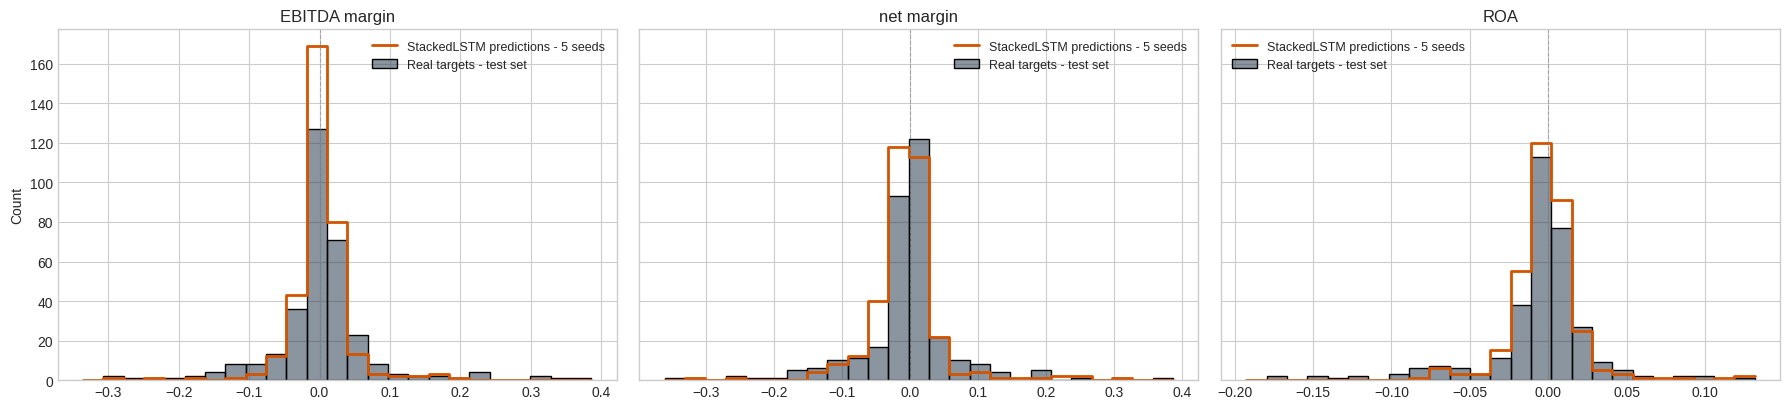

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

PRED_COLOR, TARGET_COLOR = '#d35400', '#2c3e50'

def _ratio_bins(data):
    lo, hi = np.percentile(data, [1, 99])
    bw = max((hi - lo) * 0.04, 1e-4)
    return np.arange(lo, hi + bw, bw)

def _ens_preds(per_ratio, key):
    """Mean predictions across seeds; truths/te_years are seed-invariant -> seed 0."""
    preds = np.mean(np.stack(per_ratio[key]['preds'], axis=0), axis=0)
    truths = per_ratio[key]['truths'][0]
    return preds, truths

def plot_predictions_vs_targets(per_ratio, model_name="StackedLSTM", tag=""):
    with plt.style.context('seaborn-v0_8-whitegrid'):
        fig, axes = plt.subplots(1, len(TARGETS), figsize=(18, 4.2), sharey='all')
        for ax, (key, lab, num, den) in zip(axes, TARGETS):
            pred, true = _ens_preds(per_ratio, key)
            pred, true = pred[np.isfinite(pred)], true[np.isfinite(true)]
            bins = _ratio_bins(np.concatenate([pred, true]))
            sns.histplot(true, bins=bins, kde=False, ax=ax, color=TARGET_COLOR,
                         alpha=0.55, label='Real targets - test set')
            sns.histplot(pred, bins=bins, kde=False, ax=ax, color=PRED_COLOR,
                         element='step', fill=False, linewidth=2.0,
                         label=f'{model_name} predictions{tag}')
            ax.set_title(f"{lab}")
            ax.axvline(0, color='#7f8c8d', linewidth=0.8, linestyle='--', alpha=0.6)
            if ax is axes[0]:
                ax.set_ylabel('Count')
            ax.legend(fontsize=9)
        plt.tight_layout(); plt.show()

def robust_corr(pred_list, true_list, years):
    """Pooled and within-year-demeaned Pearson corr & R2, mean/std over seeds."""
    pooled_c, pooled_r2, yd_c, yd_r2 = [], [], [], []
    for s in range(len(pred_list)):
        p, t = pred_list[s], true_list[s]
        p = p[np.isfinite(p)]; t = t[np.isfinite(t)]
        pr, _ = pearsonr(p, t)
        pooled_c.append(pr)
        pooled_r2.append(1.0 - np.mean((t - p) ** 2) / (np.var(t) + 1e-12))
        pc, tc = [], []
        for yr in np.unique(years):
            m = years == yr
            pc.append(p[m] - p[m].mean()); tc.append(t[m] - t[m].mean())
        pc, tc = np.concatenate(pc), np.concatenate(tc)
        dr, _ = pearsonr(pc, tc)
        yd_c.append(dr)
        yd_r2.append(1.0 - np.mean((tc - pc) ** 2) / (np.var(tc) + 1e-12))
    a = np.array([pooled_c, pooled_r2, yd_c, yd_r2])
    return a.mean(1), a.std(1)

rows = []
for key, lab, num, den in TARGETS:
    r = lstm_results[key]
    mu, sd = robust_corr(r['preds'], r['truths'], r['te_years'])
    rows.append({
        "Target": lab,
        "corr": f"{mu[0]:+.3f} ± {sd[0]:.3f}",
        "R2": f"{mu[1]:+.3f} ± {sd[1]:.3f}",
        "corr(yr-dm)": f"{mu[2]:+.3f} ± {sd[2]:.3f}",
        "R2(yr-dm)": f"{mu[3]:+.3f} ± {sd[3]:.3f}"
    })

df_metrics = pd.DataFrame(rows).set_index("Target")
print(f"\nEvaluation metrics (mean ± sd, n={N_SEEDS}):")
print(df_metrics.to_string())


plot_predictions_vs_targets(lstm_results, tag=f" - 5 seeds")

### Training & validation curves

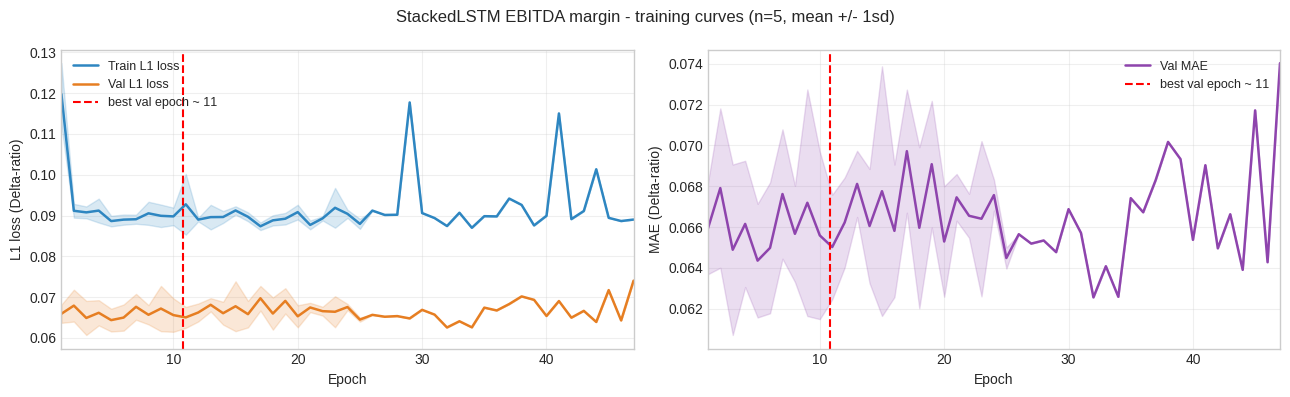

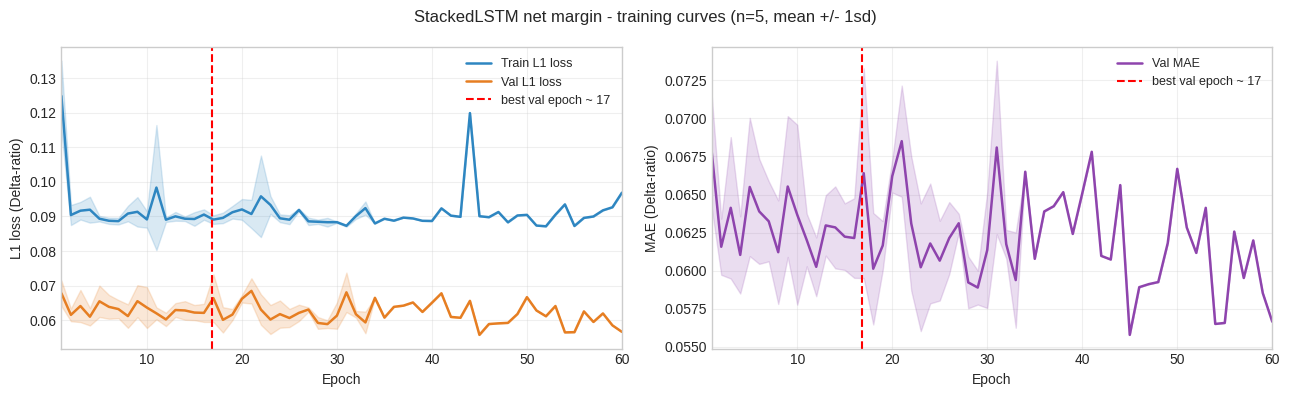

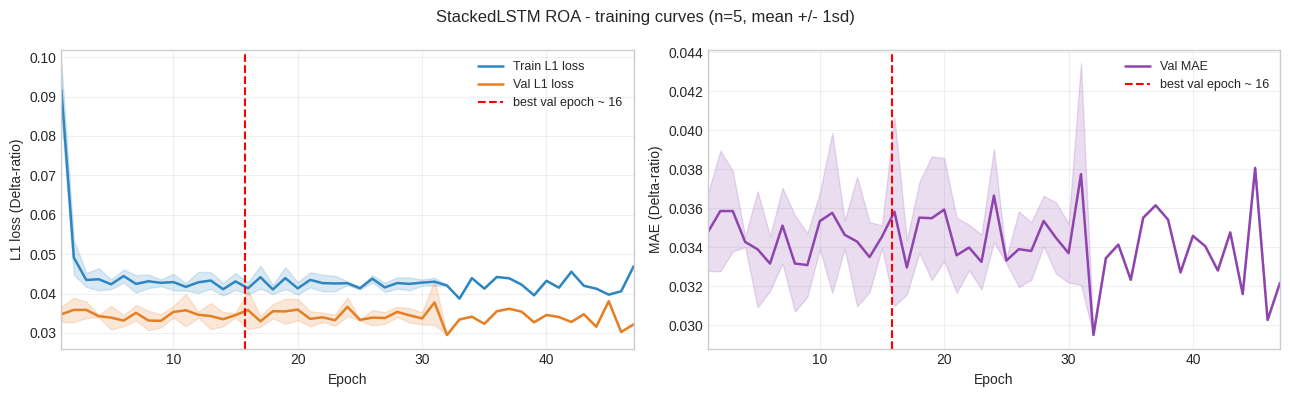

In [7]:
def plot_training_curves(histories, model_name, tag=None):
    max_ep = max(len(h['val_mae']) for h in histories)
    ep = np.arange(1, max_ep + 1)
    tr = np.full((len(histories), max_ep), np.nan)
    va = np.full((len(histories), max_ep), np.nan)
    for i, h in enumerate(histories):
        tr[i, :len(h['train_loss'])] = h['train_loss']
        va[i, :len(h['val_mae'])] = h['val_mae']
    best_epoch_mean = float(np.mean([h['best_epoch'] for h in histories]))
    title_tag = f" ({tag})" if tag else ""
    with plt.style.context('seaborn-v0_8-whitegrid'):
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.0))
        def _draw(ax, data, color, label):
            mean = np.nanmean(data, axis=0); std = np.nanstd(data, axis=0)
            ax.plot(ep, mean, color=color, linewidth=1.8, label=label)
            ax.fill_between(ep, mean - std, mean + std, color=color, alpha=0.18)
        _draw(axes[0], tr, '#2e86c1', 'Train L1 loss')
        _draw(axes[0], va, '#e67e22', 'Val L1 loss')
        _draw(axes[1], va, '#8e44ad', 'Val MAE')
        for ax in axes:
            ax.set_xlabel('Epoch'); ax.set_xlim(1, max_ep)
            ax.axvline(best_epoch_mean, color='red', linestyle='--', linewidth=1.5,
                       label=f'best val epoch ~ {best_epoch_mean:.0f}')
            ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
        axes[0].set_ylabel('L1 loss (Delta-ratio)')
        axes[1].set_ylabel('MAE (Delta-ratio)')
        fig.suptitle(f"{model_name} - training curves{title_tag} (n={len(histories)}, mean +/- 1sd)")
        plt.tight_layout(); plt.show()

for key, lab, num, den in TARGETS:
    plot_training_curves(lstm_results[key]['histories'], f"StackedLSTM {lab}")

### MTL LSTM variant

In [8]:
class MTL_StackedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, static_dim, num_targets=3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True, dropout=0.0)
        self.dropout = nn.Dropout(0.35)
        self.head = nn.Linear(hidden_size + static_dim, num_targets)

    def forward(self, x, lengths, static):
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=True)
        _, (hn, _) = self.lstm(packed)
        h = self.dropout(hn[-1])
        h = torch.cat([h, static.to(h.device, h.dtype)], dim=-1)
        return self.head(h)


class MTLDataset(Dataset):
    def __init__(self, windows, statics, labels):
        self.windows, self.statics, self.labels = windows, statics, labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return (torch.from_numpy(self.windows[i]),
                torch.from_numpy(self.statics[i]),
                torch.tensor(self.labels[i], dtype=torch.float32),
                len(self.windows[i]))


def collate_mtl(batch):
    batch.sort(key=lambda x: x[3], reverse=True)
    xs = torch.nn.utils.rnn.pad_sequence([b[0] for b in batch], batch_first=True)
    ss = torch.stack([b[1] for b in batch])
    ys = torch.stack([b[2] for b in batch])
    lens = torch.tensor([b[3] for b in batch])
    return xs, ys, ss, lens


MTL_STATIC_DIM = 3 + N_SECTORS + 9 + 2 * len(TARGETS)   # + ratio_prev & d_ratio_prev per target
MTL_STATIC_SCALE_SLICE = slice(3 + N_SECTORS, MTL_STATIC_DIM)
MTL_HIDDEN, MTL_LAYERS, MTL_BS = 64, 4, 32


def build_mtl_rows(lookback_days=365):
    cols = ['Company', 'year']
    for key, lab, num, den in TARGETS:
        cols += [key + '_prev', 'd' + key + '_prev', 'd' + key]
    have = ye[cols].dropna().copy()
    rows = []
    for (company, year), grp in have.groupby(['Company', 'year']):
        yr = int(year)
        comp = full[full['Company'] == company]
        ye_dates = comp[comp['year'] == yr]['Date']
        if ye_dates.empty:
            continue
        ye_date = ye_dates.max()
        window = comp[(comp['Date'] > ye_date - pd.Timedelta(days=lookback_days)) & (comp['Date'] <= ye_date)]
        if len(window) < 30:
            continue
        w = window[FEAT_LIST].ffill().bfill()
        if w.isna().any().any():
            continue
        mc = window[['MC_MIB', 'MC_MID', 'MC_SMALL']].iloc[-1].to_numpy(np.float32)
        prior = window[PRIOR_COLS].iloc[-1].to_numpy(np.float32)
        r = grp.iloc[0]
        extra = np.concatenate([np.array([r[k + '_prev'], r['d' + k + '_prev']], dtype=np.float32)
                                for k, lab, n, d in TARGETS])
        static = np.concatenate([mc, prior, extra])
        labels = np.array([r['d' + k] for k, lab, n, d in TARGETS], dtype=np.float32)
        rows.append(dict(company=company, year=yr, window=w.to_numpy(np.float32),
                         static=static, sector=str(window['Sector'].iloc[-1]), label=labels))
    return pd.DataFrame(rows)


def run_mtl(n_seeds=5):
    df = build_mtl_rows()
    oh = {s: np.array([1.0 if s == sec else 0.0 for sec in SECTOR_LIST], dtype=np.float32)
          for s in SECTOR_LIST}
    df['static_full'] = df.apply(
        lambda r: np.concatenate([r['static'][:3], oh[r['sector']], r['static'][3:]]).astype(np.float32), axis=1)
    tr = df[df['year'] <= 2022].reset_index(drop=True)
    va = df[df['year'] == 2023].reset_index(drop=True)
    te = df[df['year'] > 2023].reset_index(drop=True)

    scale = np.vstack(tr['label'].values).std(axis=0) + 1e-8
    scale_t = torch.tensor(scale, dtype=torch.float32, device=DEVICE)
    win_scaler = RobustScaler().fit(np.vstack(tr['window'].values))
    st_scaler = RobustScaler().fit(np.vstack([s[MTL_STATIC_SCALE_SLICE] for s in tr['static_full'].values]))

    def scaled(sub):
        wins = [np.nan_to_num(win_scaler.transform(w), nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
                for w in sub['window'].values]
        statics = []
        for s in sub['static_full'].values:
            s = s.copy()
            s[MTL_STATIC_SCALE_SLICE] = st_scaler.transform(s[MTL_STATIC_SCALE_SLICE].reshape(1, -1)).reshape(-1)
            statics.append(np.nan_to_num(s, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32))
        return MTLDataset(wins, statics, np.vstack(sub['label'].values).astype(np.float32))

    tr_ds, va_ds, te_ds = scaled(tr), scaled(va), scaled(te)
    tr_loader = DataLoader(tr_ds, batch_size=MTL_BS, shuffle=True, collate_fn=collate_mtl)
    va_loader = DataLoader(va_ds, batch_size=MTL_BS, shuffle=False, collate_fn=collate_mtl)
    te_loader = DataLoader(te_ds, batch_size=MTL_BS, shuffle=False, collate_fn=collate_mtl)

    order = []
    for i in range(0, len(te_ds), MTL_BS):
        b = list(range(i, min(i + MTL_BS, len(te_ds))))
        b.sort(key=lambda idx: te_ds[idx][3], reverse=True)
        order.extend(b)
    te_years = te['year'].to_numpy()[np.array(order)].astype(int)

    def eval_loader(loader):
        preds, truths = [], []
        with torch.no_grad():
            for xs, ys, ss, lens in loader:
                preds.append(model(xs.to(DEVICE), lens, ss.to(DEVICE)).cpu().numpy() * scale)
                truths.append(ys.numpy())
        return np.concatenate(preds), np.concatenate(truths)

    per_key_preds = {k: [] for k, lab, n, d in TARGETS}
    per_key_truths = {k: [] for k, lab, n, d in TARGETS}
    pre_list, mae_list, histories = [], [], []
    for s in range(n_seeds):
        torch.manual_seed(SEED + s); np.random.seed(SEED + s)
        model = MTL_StackedLSTM(len(FEAT_LIST), MTL_HIDDEN, MTL_LAYERS, MTL_STATIC_DIM).to(DEVICE)
        model.eval()
        p0, t0 = eval_loader(te_loader)
        pre_list.append(np.mean(np.abs(p0 - t0), axis=0))
        opt = torch.optim.Adam(model.parameters(), lr=0.00596, weight_decay=0.000217)
        criterion = nn.L1Loss()
        best = float('inf'); best_state = None; no_imp = 0
        tr_loss, va_mae = [], []
        for ep in range(1, MAX_EPOCHS + 1):
            model.train()
            ep_loss, nb = 0.0, 0
            for xs, ys, ss, lens in tr_loader:
                xs, ys, ss = xs.to(DEVICE), ys.to(DEVICE), ss.to(DEVICE)
                opt.zero_grad()
                loss = criterion(model(xs, lens, ss) / scale_t, ys / scale_t)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
                ep_loss += loss.item(); nb += 1
            tr_loss.append(ep_loss / max(nb, 1))
            model.eval()
            p, t = eval_loader(va_loader)
            vm = float(np.mean(np.abs(p - t)))
            va_mae.append(vm)
            if vm < best:
                best = vm; best_state = {k: v.clone() for k, v in model.state_dict().items()}; no_imp = 0
            else:
                no_imp += 1
            if no_imp >= PATIENCE:
                break
        histories.append(dict(train_loss=np.array(tr_loss), val_mae=np.array(va_mae),
                              best_epoch=int(np.argmin(va_mae)) + 1))
        model.load_state_dict(best_state)
        model.eval()
        p, t = eval_loader(te_loader)
        for j, (key, lab, n, d) in enumerate(TARGETS):
            per_key_preds[key].append(p[:, j])
            per_key_truths[key].append(t[:, j])
        mae_list.append(np.mean(np.abs(p - t), axis=0))  # (3,)
    mae = np.mean(np.array(mae_list), axis=0); mae_sd = np.std(np.array(mae_list), axis=0)
    pre = np.mean(np.array(pre_list), axis=0); pre_sd = np.std(np.array(pre_list), axis=0)
    return dict(pre=pre, presd=pre_sd, mae=mae, mae_sd=mae_sd,
                preds=per_key_preds, truths=per_key_truths, te_years=te_years, histories=histories)


mtl = run_mtl(n_seeds=5)
print(f"{'target':16s} {'untrained':>10s} {'MTL MAE':>9s} {'train gain':>11s}")
for j, (key, lab, n, d) in enumerate(TARGETS):
    print(f"{lab:16s} {mtl['pre'][j]:10.4f} {mtl['mae'][j]:9.4f} "
          f"{1-mtl['mae'][j]/mtl['pre'][j]:+11.3f}")

target            untrained   MTL MAE  train gain
EBITDA margin        0.0912    0.0642      +0.295
net margin           0.0824    0.0589      +0.285
ROA                  0.0361    0.0289      +0.200


### MTL corr / R² + distribution

target                        corr                R2         corr(yr-dm)         R2(yr-dm)
EBITDA margin    0.400+-0.026 0.065+-0.021 0.396+-0.025 0.065+-0.021
net margin       0.459+-0.018 0.097+-0.011 0.458+-0.018 0.098+-0.011
ROA              0.218+-0.089 0.011+-0.011 0.218+-0.089 0.018+-0.010


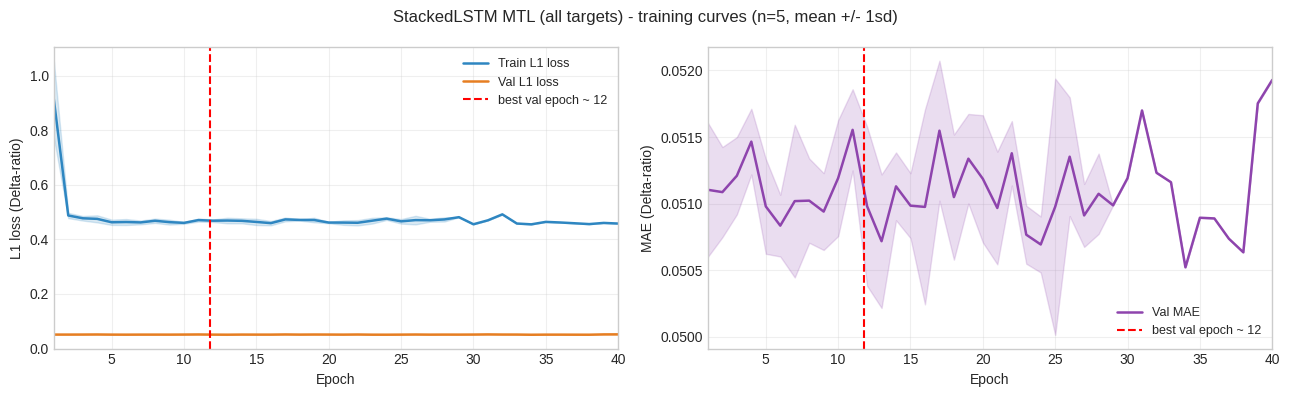

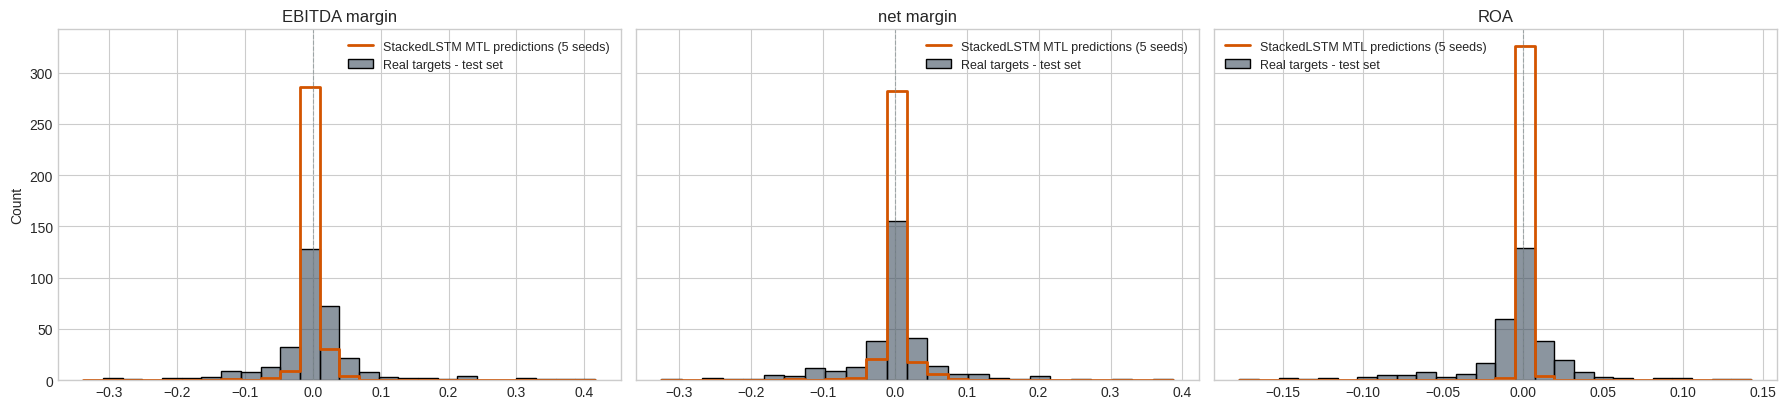

In [9]:
print(f"{'target':16s} {'corr':>17s} {'R2':>17s} {'corr(yr-dm)':>19s} {'R2(yr-dm)':>17s}")
for key, lab, n, d in TARGETS:
    mu, sd = robust_corr(mtl['preds'][key], mtl['truths'][key], mtl['te_years'])
    print(f"{lab:16s} {mu[0]:.3f}+-{sd[0]:.3f} {mu[1]:.3f}+-{sd[1]:.3f} "
          f"{mu[2]:.3f}+-{sd[2]:.3f} {mu[3]:.3f}+-{sd[3]:.3f}")

plot_training_curves(mtl['histories'], "StackedLSTM MTL (all targets)")

mtl_plot = {key: {'preds': mtl['preds'][key], 'truths': mtl['truths'][key]}
            for key, lab, n, d in TARGETS}
plot_predictions_vs_targets(mtl_plot, model_name="StackedLSTM MTL", tag=" (5 seeds)")


## Summary

In [10]:
# 1. Linear models
h1 = f"{'Target':<16} {'AR(1)':>10} {'Partial':>10} {'Gain (part/AR1)':>18}"
print("=== Linear models (walk-forward 2012-2025) ===")
print(h1)
print("-" * len(h1))
for key, lab, num, den in TARGETS:
    lr = linear_results[key]
    gain = 1.0 - (lr['partial'] / lr['ar1'])
    print(f"{lab:<16} {lr['ar1']:10.4f} {lr['partial']:10.4f} {gain:+18.3f}")

# 2. LSTM
h2 = f"{'Target':<16} {'Untrained':>12} {'Trained':>10} {'Train Gain':>13}"
print("\n=== LSTM (train<=2022, val=2023, test=2024+2025) ===")
print(h2)
print("-" * len(h2))
for key, lab, num, den in TARGETS:
    ls = lstm_results[key]
    gain = 1.0 - (ls['mae'] / ls['pre'])
    print(f"{lab:<16} {ls['pre']:12.4f} {ls['mae']:10.4f} {gain:+13.3f}")

# 3. MTL LSTM
print("\n=== MTL LSTM (train<=2022, val=2023, test=2024+2025) ===")
print(h2)
print("-" * len(h2))
for j, (key, lab, n, d) in enumerate(TARGETS):
    pre, mae = mtl['pre'][j], mtl['mae'][j]
    gain = 1.0 - (mae / pre)
    print(f"{lab:<16} {pre:12.4f} {mae:10.4f} {gain:+13.3f}")

# 4. LSTM corr / R2
h4 = f"{'Target':<16} {'corr':>16} {'R2':>16} {'corr(yr-dm)':>16} {'R2(yr-dm)':>16}"
print(f"\n=== LSTM corr / R2 (mean +- sd over seeds, n={N_SEEDS}) ===")
print(h4)
print("-" * len(h4))
for key, lab, num, den in TARGETS:
    r = lstm_results[key]
    mu, sd = robust_corr(r['preds'], r['truths'], r['te_years'])

    c_p   = f"{mu[0]:+.3f}±{sd[0]:.3f}"
    r2_p  = f"{mu[1]:+.3f}±{sd[1]:.3f}"
    c_yd  = f"{mu[2]:+.3f}±{sd[2]:.3f}"
    r2_yd = f"{mu[3]:+.3f}±{sd[3]:.3f}"

    print(f"{lab:<16} {c_p:>16} {r2_p:>16} {c_yd:>16} {r2_yd:>16}")

=== Linear models (walk-forward 2012-2025) ===
Target                AR(1)    Partial    Gain (part/AR1)
---------------------------------------------------------
EBITDA margin        0.0859     0.0896             -0.043
net margin           0.0849     0.0891             -0.049
ROA                  0.0372     0.0365             +0.020

=== LSTM (train<=2022, val=2023, test=2024+2025) ===
Target              Untrained    Trained    Train Gain
------------------------------------------------------
EBITDA margin          0.2094     0.0653        +0.688
net margin             0.2219     0.0627        +0.717
ROA                    0.1913     0.0316        +0.835

=== MTL LSTM (train<=2022, val=2023, test=2024+2025) ===
Target              Untrained    Trained    Train Gain
------------------------------------------------------
EBITDA margin          0.0912     0.0642        +0.295
net margin             0.0824     0.0589        +0.285
ROA                    0.0361     0.0289        +0.200

